In [1]:
# CELDA 1: Importaciones
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

# Permite importar scripts/ desde NASA/notebooks
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from scripts.database import engine

PLOTS = ROOT / "data" / "graficas"
PLOTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})
print("Importaciones OK")

Importaciones OK


In [ ]:
# CELDA 2: Carga de datos desde Supabase/PostgreSQL
QUERY = """
SELECT
    nasa_id,
    nombre,
    magnitud_absoluta,
    diametro_min_km,
    diametro_max_km,
    es_peligroso,
    fecha_aproximacion,
    velocidad_km_s,
    distancia_km,
    fecha_extraccion
FROM asteroides
ORDER BY fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
df.head()

In [12]:
# CELDA 3: Preparación de variables
work = df.copy()

# Unificar timezone: convierte ambas fechas a UTC y luego elimina tz para evitar errores tz-aware vs tz-naive
work["fecha_aproximacion"] = pd.to_datetime(work["fecha_aproximacion"], errors="coerce", utc=True).dt.tz_localize(None)
work["fecha_extraccion"] = pd.to_datetime(work["fecha_extraccion"], errors="coerce", utc=True).dt.tz_localize(None)

# Conversión robusta de booleano/flag a 0/1 (sin FutureWarning de replace)
val_map = {
    "true": 1,
    "false": 0,
    "t": 1,
    "f": 0,
    "1": 1,
    "0": 0,
    "1.0": 1,
    "0.0": 0,
}

es_peligroso_str = work["es_peligroso"].astype("string").str.strip().str.lower()
work["es_peligroso"] = es_peligroso_str.map(val_map)

# Fallback para casos ya numéricos no mapeados explícitamente
mask_na = work["es_peligroso"].isna()
work.loc[mask_na, "es_peligroso"] = pd.to_numeric(es_peligroso_str[mask_na], errors="coerce")

# Feature engineering
work["diametro_promedio_km"] = (work["diametro_min_km"] + work["diametro_max_km"]) / 2
work["dias_hasta_aprox"] = (work["fecha_aproximacion"] - work["fecha_extraccion"].dt.normalize()).dt.days

# Objetivo
TARGET = "distancia_km"

numericas = [
    "magnitud_absoluta",
    "diametro_min_km",
    "diametro_max_km",
    "diametro_promedio_km",
    "es_peligroso",
    "velocidad_km_s",
    "dias_hasta_aprox",
    TARGET,
]

model_df = work[numericas].replace([np.inf, -np.inf], np.nan).dropna().copy()
model_df["es_peligroso"] = model_df["es_peligroso"].astype(int)

print("Dataset modelado:", model_df.shape)
print("Nulos por columna:")
print(model_df.isna().sum())
model_df.head()

Dataset modelado: (87, 8)
Nulos por columna:
magnitud_absoluta       0
diametro_min_km         0
diametro_max_km         0
diametro_promedio_km    0
es_peligroso            0
velocidad_km_s          0
dias_hasta_aprox        0
distancia_km            0
dtype: int64


,magnitud_absoluta,diametro_min_km,diametro_max_km,diametro_promedio_km,es_peligroso,velocidad_km_s,dias_hasta_aprox,distancia_km
0,22.17,0.097849,0.218796,0.158322,0,13.443594,7,2.956038e+07
1,19.57,0.324007,0.724503,0.524255,0,29.337152,7,3.848995e+07
2,21.95,0.108282,0.242125,0.175203,0,11.450993,7,8.675495e+06
3,24.41,0.034878,0.077990,0.056434,0,26.655534,7,4.165358e+07
4,24.60,0.031956,0.071456,0.051706,0,5.739435,7,2.654876e+07


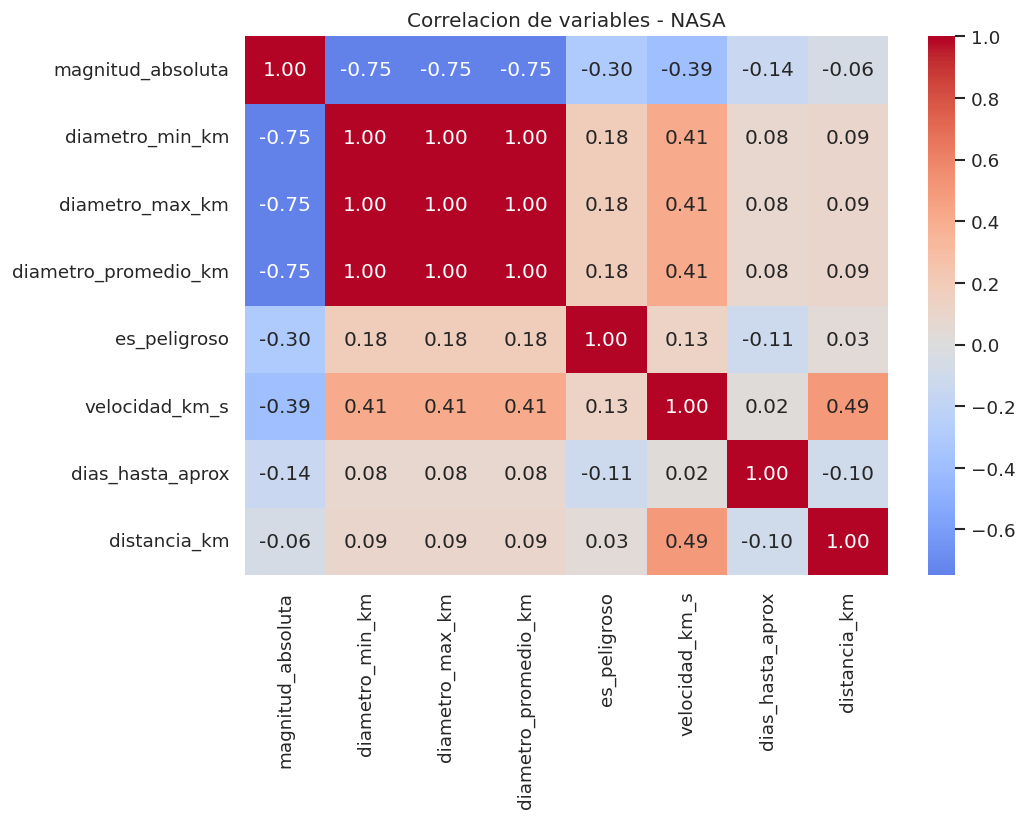

Correlacion con distancia_km:
velocidad_km_s          0.488162
dias_hasta_aprox       -0.095601
diametro_min_km         0.093123
diametro_promedio_km    0.093123
diametro_max_km         0.093123
magnitud_absoluta      -0.057514
es_peligroso            0.033137
Name: distancia_km, dtype: float64


In [4]:
# CELDA 4: EDA rapido (correlacion)
corr = model_df.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacion de variables - NASA")
plt.tight_layout()
plt.savefig(PLOTS / "nasa_correlacion.png", bbox_inches="tight")
plt.show()

print("Correlacion con distancia_km:")
print(corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False))

In [5]:
# CELDA 5: Seleccion optima para regresion lineal simple
CANDIDATAS = [c for c in model_df.columns if c != TARGET]
ranking_simple = []

for col in CANDIDATAS:
    X = sm.add_constant(model_df[[col]])
    m = sm.OLS(model_df[TARGET], X).fit()
    ranking_simple.append({
        "variable": col,
        "R2": m.rsquared,
        "AIC": m.aic,
        "pvalue_variable": m.pvalues[col]
    })

ranking_simple_df = pd.DataFrame(ranking_simple).sort_values(by=["R2", "AIC"], ascending=[False, True])
FEATURE_SIMPLE = ranking_simple_df.iloc[0]["variable"]
ranking_simple_df

,variable,R2,AIC,pvalue_variable
5,velocidad_km_s,0.238303,3156.383971,0.000002
6,dias_hasta_aprox,0.009140,3179.267077,0.378409
1,diametro_min_km,0.008672,3179.308139,0.390951
3,diametro_promedio_km,0.008672,3179.308139,0.390951
2,diametro_max_km,0.008672,3179.308139,0.390951
0,magnitud_absoluta,0.003308,3179.777616,0.596711
4,es_peligroso,0.001098,3179.970295,0.760598


In [6]:
# CELDA 6: Seleccion optima para regresion multiple (busqueda exhaustiva)
resultados_multi = []

for k in range(2, len(CANDIDATAS) + 1):
    for subset in combinations(CANDIDATAS, k):
        X = sm.add_constant(model_df[list(subset)])
        m = sm.OLS(model_df[TARGET], X).fit()
        resultados_multi.append({
            "variables": subset,
            "k": k,
            "R2_adj": m.rsquared_adj,
            "AIC": m.aic,
            "BIC": m.bic
        })

ranking_multi_df = pd.DataFrame(resultados_multi).sort_values(by=["AIC", "BIC", "R2_adj"], ascending=[True, True, False])
FEATURES_MULTI = list(ranking_multi_df.iloc[0]["variables"])
ranking_multi_df.head(10)

,variables,k,R2_adj,AIC,BIC
4,"(magnitud_absoluta, velocidad_km_s)",2,0.241119,3156.014554,3163.412279
13,"(diametro_max_km, velocidad_km_s)",2,0.234445,3156.776276,3164.174000
16,"(diametro_promedio_km, velocidad_km_s)",2,0.234445,3156.776276,3164.174000
9,"(diametro_min_km, velocidad_km_s)",2,0.234445,3156.776276,3164.174000
20,"(velocidad_km_s, dias_hasta_aprox)",2,0.231532,3157.106669,3164.504393
35,"(magnitud_absoluta, velocidad_km_s, dias_hasta...",3,0.239529,3157.154696,3167.018328
51,"(diametro_max_km, velocidad_km_s, dias_hasta_a...",3,0.234757,3157.698864,3167.562496
54,"(diametro_promedio_km, velocidad_km_s, dias_ha...",3,0.234757,3157.698864,3167.562496
45,"(diametro_min_km, velocidad_km_s, dias_hasta_a...",3,0.234757,3157.698864,3167.562496
28,"(magnitud_absoluta, diametro_max_km, velocidad...",3,0.232629,3157.940457,3167.804089


In [7]:
# CELDA 7: Entrenamiento y evaluacion - modelo simple
X_s = model_df[[FEATURE_SIMPLE]].values
y = model_df[TARGET].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y, test_size=0.2, random_state=42)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)
pred_s = modelo_simple.predict(X_test_s)

met_simple = {
    "modelo": "simple",
    "variables": FEATURE_SIMPLE,
    "R2": r2_score(y_test_s, pred_s),
    "MAE": mean_absolute_error(y_test_s, pred_s),
    "RMSE": np.sqrt(mean_squared_error(y_test_s, pred_s))
}
met_simple

{'modelo': 'simple',
 'variables': 'velocidad_km_s',
 'R2': 0.2994982259428396,
 'MAE': 16019259.770925999,
 'RMSE': 18604554.55712883}

In [8]:
# CELDA 8: Entrenamiento y evaluacion - modelo multiple
X_m = model_df[FEATURES_MULTI].values
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y, test_size=0.2, random_state=42)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
pred_m = modelo_multi.predict(X_test_m)

met_multi = {
    "modelo": "multiple",
    "variables": ", ".join(FEATURES_MULTI),
    "R2": r2_score(y_test_m, pred_m),
    "MAE": mean_absolute_error(y_test_m, pred_m),
    "RMSE": np.sqrt(mean_squared_error(y_test_m, pred_m))
}
met_multi

{'modelo': 'multiple',
 'variables': 'magnitud_absoluta, velocidad_km_s',
 'R2': 0.3023729613513668,
 'MAE': 15331465.714060541,
 'RMSE': 18566340.40979998}

In [9]:
# CELDA 9: Inferencia OLS y VIF del modelo multiple
ols_simple = sm.OLS(model_df[TARGET], sm.add_constant(model_df[[FEATURE_SIMPLE]])).fit()
ols_multi = sm.OLS(model_df[TARGET], sm.add_constant(model_df[FEATURES_MULTI])).fit()

print("=== OLS SIMPLE ===")
print(ols_simple.summary())
print("\n=== OLS MULTIPLE ===")
print(ols_multi.summary())

X_vif = model_df[FEATURES_MULTI]
vif_df = pd.DataFrame({
    "variable": FEATURES_MULTI,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)
print("\nVIF modelo multiple")
vif_df

=== OLS SIMPLE ===
                            OLS Regression Results                            
Dep. Variable:           distancia_km   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     26.59
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.62e-06
Time:                        20:31:03   Log-Likelihood:                -1576.2
No. Observations:                  87   AIC:                             3156.
Df Residuals:                      85   BIC:                             3161.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.802e+07

,variable,VIF
0,magnitud_absoluta,3.902279
1,velocidad_km_s,3.902279


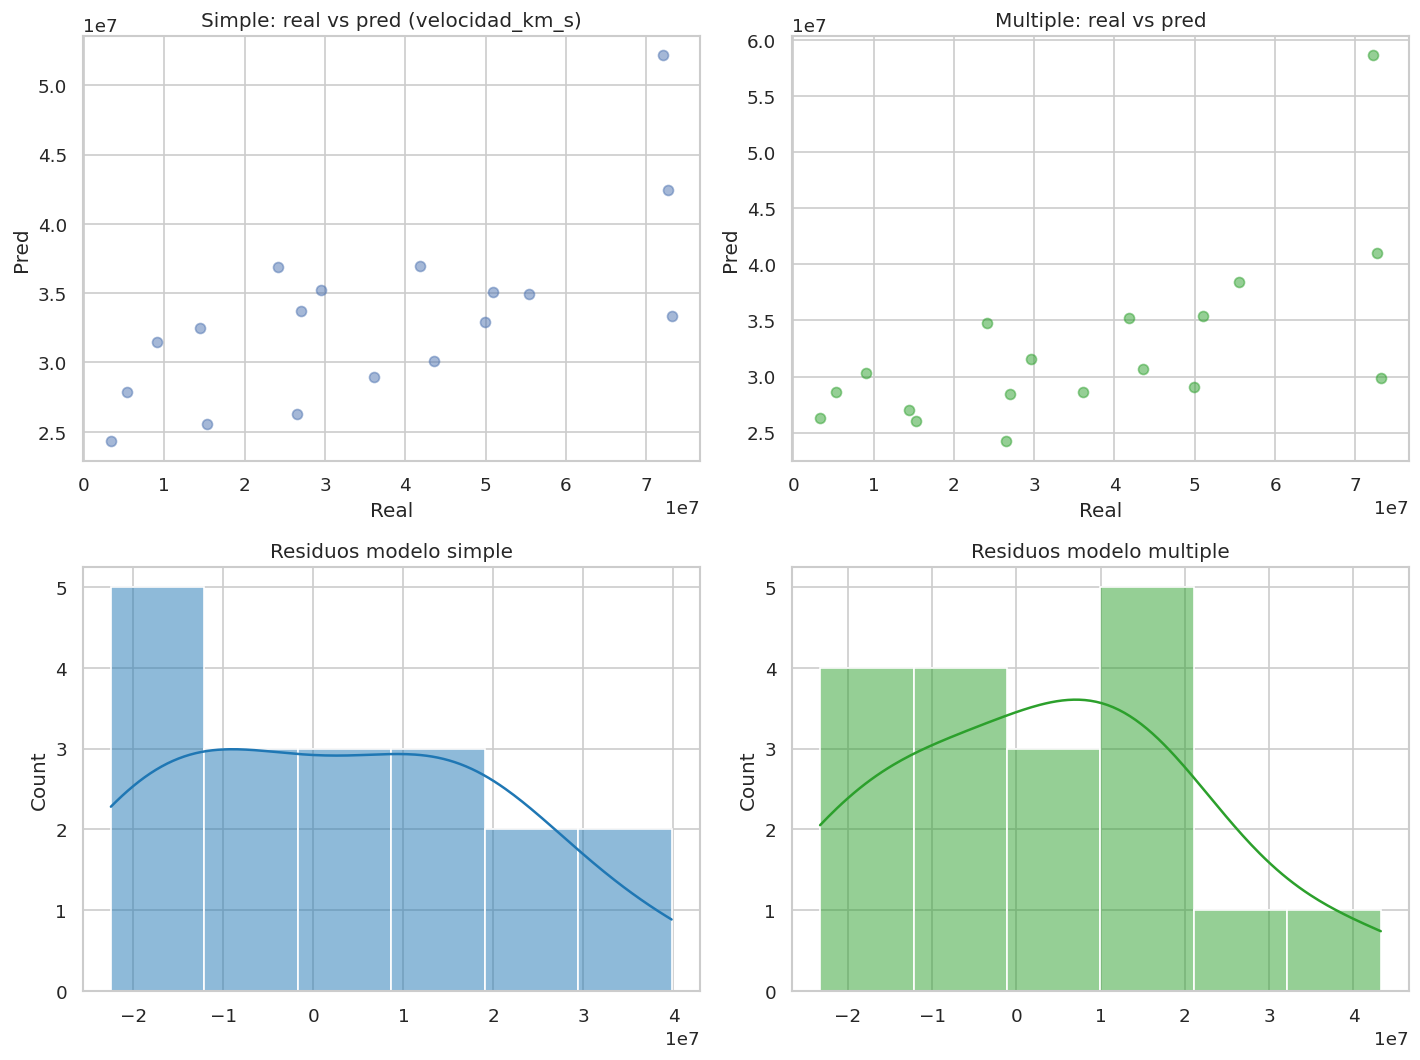

Shapiro simple p-value: 0.430651
Shapiro multiple p-value: 0.695554

Comparacion final


,modelo,variables,R2,MAE,RMSE
1,multiple,"magnitud_absoluta, velocidad_km_s",0.302373,1.533147e+07,1.856634e+07
0,simple,velocidad_km_s,0.299498,1.601926e+07,1.860455e+07


In [10]:
# CELDA 10: Diagnosticos y comparacion final
res_simple = y_test_s - pred_s
res_multi = y_test_m - pred_m

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].scatter(y_test_s, pred_s, alpha=0.5)
axes[0,0].set_title(f"Simple: real vs pred ({FEATURE_SIMPLE})")
axes[0,0].set_xlabel("Real")
axes[0,0].set_ylabel("Pred")

axes[0,1].scatter(y_test_m, pred_m, alpha=0.5, color="tab:green")
axes[0,1].set_title("Multiple: real vs pred")
axes[0,1].set_xlabel("Real")
axes[0,1].set_ylabel("Pred")

sns.histplot(res_simple, kde=True, ax=axes[1,0], color="tab:blue")
axes[1,0].set_title("Residuos modelo simple")

sns.histplot(res_multi, kde=True, ax=axes[1,1], color="tab:green")
axes[1,1].set_title("Residuos modelo multiple")

plt.tight_layout()
plt.savefig(PLOTS / "nasa_modelos_comparacion.png", bbox_inches="tight")
plt.show()

sw_s = shapiro(res_simple)
sw_m = shapiro(res_multi)

comparacion = pd.DataFrame([met_simple, met_multi]).sort_values("RMSE")
print("Shapiro simple p-value:", round(sw_s.pvalue, 6))
print("Shapiro multiple p-value:", round(sw_m.pvalue, 6))
print("\nComparacion final")
comparacion